In [1]:
import os, sys
import pyspark

os.environ["PYSPARK_PYTHON"]=sys.executable          # Worker가 사용할 Python 실행 파일 경로 설정 (리눅스 "/usr/bin/python3")
os.environ["PYSPARK_DRIVER_PYTHON"]=sys.executable   # Driver에서도 동일한 Python 경로 설정
# os.environ['HADOOP_HOME']=os.getcwd() # 현재 디렉터리를 HADOOP_HOME으로 설정
# os.environ["PATH"] += os.path.join(os.environ['HADOOP_HOME'], 'bin') # PATH에 Hadoop 바이너리 추가

myConf=pyspark.SparkConf() # 기본 설정 객체 생성, 여기에 필요한 설정 정의
# myConf=pyspark.SparkConf().set("spark.driver.bindAddress", "127.0.0.1") #드라이버 바인딩 주소 설정
# myConf=pyspark.SparkConf().set("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.13:10.1.1") 

spark = pyspark.sql.SparkSession\
    .builder\
    .master("local")\
    .appName("test")\
    .config(conf=myConf)\
    .getOrCreate()

In [6]:
myList=[
        ('1','kim, js', 170),
        ('1','lee, sm', 175),
        ('2','lim, yg',180),
        ('2','lee', 170)
]

In [7]:
myDf=spark.createDataFrame(myList)

In [8]:
myDf.columns

['_1', '_2', '_3']

In [9]:
myDf.printSchema()

root
 |-- _1: string (nullable = true)
 |-- _2: string (nullable = true)
 |-- _3: long (nullable = true)



In [10]:
print (myDf.take(1))

[Row(_1='1', _2='kim, js', _3=170)]


In [11]:
#조건문 :select, when, otherwise

In [12]:
#when은 if문과 거의 비슷

In [13]:
myDf=myDf.withColumnRenamed('_1','year').withColumnRenamed('_2','name').withColumnRenamed('_3','height')

In [14]:
myDf.printSchema()

root
 |-- year: string (nullable = true)
 |-- name: string (nullable = true)
 |-- height: long (nullable = true)



In [15]:
#udf 파이썬에서 직접 함수를 쓸 수 없기 때문임 (약자를 외우면 된다)

In [17]:

def uppercase(s):
    return s.upper()

In [18]:
uppercase("a")


'A'

In [19]:
from pyspark.sql.functions import when
myDf.select("height", when(myDf.height < 175, 1).otherwise(0)).show()

+------+------------------------------------------+
|height|CASE WHEN (height < 175) THEN 1 ELSE 0 END|
+------+------------------------------------------+
|   170|                                         1|
|   175|                                         0|
|   180|                                         0|
|   170|                                         1|
+------+------------------------------------------+



In [20]:
#when & othrewise로 if문을 대신하고 있다

In [22]:
from pyspark.sql.functions import when
myDf.select("height", 
            when(myDf.height <= 170, 1)
            .when((myDf.height > 170) & (myDf.height <= 175), 2)
            .otherwise(0)
           )\
    .show()

#colum 명을 따로 주지 않았기 때문에

+------+--------------------------------------------------------------------------------------------+
|height|CASE WHEN (height <= 170) THEN 1 WHEN ((height > 170) AND (height <= 175)) THEN 2 ELSE 0 END|
+------+--------------------------------------------------------------------------------------------+
|   170|                                                                                           1|
|   175|                                                                                           2|
|   180|                                                                                           0|
|   170|                                                                                           1|
+------+--------------------------------------------------------------------------------------------+



In [23]:
#when 조건문 중첩 -> if문 중첩

In [24]:
#alias 명령어로 컬럼을 변경해 줄 수 있다.
#위에 너무 길었잖아

from pyspark.sql.functions import when
myDf.select("height", (when(myDf.height < 175, 1).otherwise(0)).alias('<175')).show()

+------+----+
|height|<175|
+------+----+
|   170|   1|
|   175|   0|
|   180|   0|
|   170|   1|
+------+----+



In [25]:
#dataframe을 ML로 넘겨줘야해서 data가공이 필요하다

In [26]:
#alias :: 별칭을 짓는 것

In [32]:
from pyspark.sql.functions import when
_myDf=myDf.select(when(myDf['heightD'] >175.0, ">175").otherwise("<175").alias("how tall"))

In [33]:
#with 컬럼 :: 컬럼을 생성 (붙여주는 명령어)

In [34]:

_myDf = myDf.withColumn('how tall', when(myDf['heightD'] >175.0, ">175").otherwise("<175"))
_myDf.show()

+----+-------+------+-------+--------+
|year|   name|height|heightD|how tall|
+----+-------+------+-------+--------+
|   1|kim, js|   170|  170.0|    <175|
|   1|lee, sm|   175|  175.0|    <175|
|   2|lim, yg|   180|  180.0|    >175|
|   2|    lee|   170|  170.0|    <175|
+----+-------+------+-------+--------+



In [35]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

toDoublefunc = udf(lambda x: float(x), DoubleType())
myDf = myDf.withColumn("heightD", toDoublefunc(myDf.height))

In [36]:
myDf.where(myDf['height'] < 175).show()
#여기서 height말고 열 번호로 써도 돼
# myDf.컬럼명
    # or myDf['컬럼번호']

+----+-------+------+-------+
|year|   name|height|heightD|
+----+-------+------+-------+
|   1|kim, js|   170|  170.0|
|   2|    lee|   170|  170.0|
+----+-------+------+-------+



In [37]:
#where 조건 
#select 고르기

In [38]:
myDf.where(myDf['height'] < 175)\
    .select(myDf['name'], myDf['height']).show()

+-------+------+
|   name|height|
+-------+------+
|kim, js|   170|
|    lee|   170|
+-------+------+



In [39]:
#select : 열
#filter : 행

myDf.filter(myDf['height'] > 175).show()

+----+-------+------+-------+
|year|   name|height|heightD|
+----+-------+------+-------+
|   2|lim, yg|   180|  180.0|
+----+-------+------+-------+



In [40]:
#filter랑 select 차이점 잘 기억하기

In [41]:
#col() 함수로 컬럼을 지정해도 된다. 이건 함수임
#col 지칭시 함수를 사용하게 되면 function에서 col을 꼭 가져와야 하는 거임

In [44]:
myDf.filter(col('height') > 175).show()

+----+-------+------+-------+
|year|   name|height|heightD|
+----+-------+------+-------+
|   2|lim, yg|   180|  180.0|
+----+-------+------+-------+



In [45]:
from pyspark.sql.functions import *

_heightDf = myDf.withColumn('nameNew', regexp_replace('name', 'lee', 'lim'))
_heightDf.show()

+----+-------+------+-------+-------+
|year|   name|height|heightD|nameNew|
+----+-------+------+-------+-------+
|   1|kim, js|   170|  170.0|kim, js|
|   1|lee, sm|   175|  175.0|lim, sm|
|   2|lim, yg|   180|  180.0|lim, yg|
|   2|    lee|   170|  170.0|    lim|
+----+-------+------+-------+-------+



In [46]:
#위에 보면 알 수 있듯 바꿔치기가 된다

In [47]:
#groupBy :: 집단화!!!!!!

In [48]:
#통계를 볼 때는 집단화해서 통계값으로 내는 게 보기도 좋아요

In [49]:
#groupBy 는 통계값이 나오지가 않음 그래서 추가로 통계 함수가 필요하다

In [50]:
#집단화하면 집단만 출력되게 된다

In [51]:
myDf.groupby(myDf['year'])

GroupedData[grouping expressions: [year: string], value: [year: string, name: string ... 2 more fields], type: GroupBy]

In [52]:
#r그래서 max도 통계값의 일종이다

In [53]:
myDf.groupby(myDf['year']).max().show()

+----+-----------+------------+
|year|max(height)|max(heightD)|
+----+-----------+------------+
|   1|        175|       175.0|
|   2|        180|       180.0|
+----+-----------+------------+



In [54]:
#col명은 그대로 출력

In [55]:
myDf.groupby(col('year')).max().show()

+----+-----------+------------+
|year|max(height)|max(heightD)|
+----+-----------+------------+
|   1|        175|       175.0|
|   2|        180|       180.0|
+----+-----------+------------+



In [56]:
#agg 함수 -> aggregate(집계)한다는 단어의 준말

In [57]:
myDf.groupBy('year').agg({"heightD":"avg"}).show()
#이렇게 average를 쓸 수 있고, 딕셔너리 형식으로 사용한다

+----+------------+
|year|avg(heightD)|
+----+------------+
|   1|       172.5|
|   2|       175.0|
+----+------------+



In [70]:
import requests

In [71]:
r=requests.get("https://raw.githubusercontent.com/jokecamp/FootballData/master/World%20Cups/all-world-cup-players.json")

In [72]:

wc=r.json()

In [80]:

from pyspark.sql import Row
wcDf = spark.createDataFrame(Row(**x) for x in wc)

In [81]:
wcDf.groupBy(wcDf.ClubCountry).count().show()

+-----------+-----+
|ClubCountry|count|
+-----------+-----+
|   England |    4|
|   Paraguay|   93|
|     Russia|   51|
|        POL|   11|
|        BRA|   27|
|    Senegal|    1|
|     Sweden|  154|
|   Colombia|    1|
|        FRA|  155|
|        ALG|    8|
|   England |    1|
|       RUS |    1|
|     Turkey|   65|
|      Zaire|   22|
|       Iraq|   22|
|    Germany|  206|
|        RSA|   16|
|        ITA|  224|
|        UKR|   38|
|        GHA|    8|
+-----------+-----+
only showing top 20 rows



In [82]:
_wcDf=spark.createDataFrame(wc)

In [83]:
_wcDf=spark.createDataFrame(wc)

In [84]:
_wcDf.groupBy(wcDf.ClubCountry).count().show()

AnalysisException: [MISSING_ATTRIBUTES.RESOLVED_ATTRIBUTE_APPEAR_IN_OPERATION] Resolved attribute(s) "ClubCountry" missing from "Club", "ClubCountry", "Competition", "DateOfBirth", "FullName", "IsCaptain", "Number", "Position", "Team", "Year" in operator !Aggregate [ClubCountry#392], [ClubCountry#392, count(1) AS count#481L]. Attribute(s) with the same name appear in the operation: "ClubCountry".
Please check if the right attribute(s) are used.;
!Aggregate [ClubCountry#392], [ClubCountry#392, count(1) AS count#481L]
+- LogicalRDD [Club#450, ClubCountry#451, Competition#452, DateOfBirth#453, FullName#454, IsCaptain#455, Number#456, Position#457, Team#458, Year#459L], false


In [ ]:
#dataframe은 col이름이 key값이다

In [85]:
#countㄴ를 이용하여 통계값 계산 가능

In [86]:
wcDf.groupBy('ClubCountry').pivot('Position').count().show()

+-----------+----+----+----+----+----+
|ClubCountry|    |  DF|  FW|  GK|  MF|
+-----------+----+----+----+----+----+
|   England |NULL|NULL|   2|NULL|   2|
|   Paraguay|NULL|  26|  37|  10|  20|
|     Russia|NULL|  20|  11|   4|  16|
|        POL|NULL|   2|   2|   3|   4|
|        BRA|NULL|   7|   5|   4|  11|
|    Senegal|NULL|NULL|NULL|   1|NULL|
|     Sweden|NULL|  40|  47|  25|  42|
|   Colombia|NULL|NULL|   1|NULL|NULL|
|        ALG|NULL|   2|NULL|   6|NULL|
|        FRA|NULL|  46|  41|  18|  50|
|   England |NULL|NULL|NULL|NULL|   1|
|       RUS |NULL|NULL|NULL|   1|NULL|
|     Turkey|NULL|  20|  13|  12|  20|
|      Zaire|NULL|   6|   5|   3|   8|
|       Iraq|NULL|   6|   4|   3|   9|
|    Germany|NULL|  64|  51|  16|  75|
|        RSA|NULL|   5|   2|   3|   6|
|        UKR|NULL|  13|   7|   4|  14|
|        ITA|NULL|  74|  42|  19|  89|
|        CMR|NULL|   1|   1|   1|NULL|
+-----------+----+----+----+----+----+
only showing top 20 rows



In [87]:
#통계값을 구하는 count

In [88]:
#중간에 null이 있는데 나중에 통계값 구할 때 문제가 될 수 있음 

In [89]:
#F함수

In [90]:
#F (=function)

In [91]:
from pyspark.sql import functions as F

myDf.agg(F.min(myDf.heightD),F.max(myDf.heightD),F.avg(myDf.heightD),F.sum(myDf.heightD)).show()

+------------+------------+------------+------------+
|min(heightD)|max(heightD)|avg(heightD)|sum(heightD)|
+------------+------------+------------+------------+
|       170.0|       180.0|      173.75|       695.0|
+------------+------------+------------+------------+



In [92]:
#pyspark에서부터 불러와서 써야 한다

In [93]:
#functions 모듈 함수에서 쓰는 것

In [94]:
#agg함수에는 보통 diction를 사용하는데 여기서는 직접 col의 함수를 쓰게 되는 거다

In [95]:
#col명이 싫으면 alies를 써야함

In [97]:
#열추가랑 다른 거임

In [98]:
#data를 만들고 uppend 써야할때 쓰는데 union함수 (합치는함수) 를 사용하게 된다

In [99]:
#그렇다면? data성격과 col의 갯수가 동일해야할 것

In [100]:
toAppendDf = spark.createDataFrame([Row(4, "choi, js", 177, "CHOI, JS", 177.0, 4)])

In [101]:
_myDf = myDf.union(toAppendDf)

AnalysisException: [NUM_COLUMNS_MISMATCH] UNION can only be performed on inputs with the same number of columns, but the first input has 4 columns and the second input has 6 columns.;
'Union false, false
:- Project [year#6, name#10, height#14L, <lambda>(height#14L)#102 AS heightD#103]
:  +- Project [year#6, name#10, height#14L, <lambda>(height#14L)#66 AS heightD#67]
:     +- Project [year#6, name#10, _3#2L AS height#14L]
:        +- Project [year#6, _2#1 AS name#10, _3#2L]
:           +- Project [_1#0 AS year#6, _2#1, _3#2L]
:              +- LogicalRDD [_1#0, _2#1, _3#2L], false
+- LogicalRDD [_1#712L, _2#713, _3#714L, _4#715, _5#716, _6#717L], false


In [102]:
#data 분산이 필요

In [105]:
myDf.rdd.getNumPartitions()

1

In [106]:
_myDf = myDf.repartition(4)
print(_myDf.rdd.getNumPartitions())

4


In [107]:
#줄일 때 쓰는 거

_myDf2 = _myDf.coalesce(2)
print(_myDf2.rdd.getNumPartitions())

2


In [108]:
#partiion은 논리적으로 나누는 것

In [109]:
myDf.describe().show()

+-------+------------------+-------+------------------+------------------+
|summary|              year|   name|            height|           heightD|
+-------+------------------+-------+------------------+------------------+
|  count|                 4|      4|                 4|                 4|
|   mean|               1.5|   NULL|            173.75|            173.75|
| stddev|0.5773502691896257|   NULL|4.7871355387816905|4.7871355387816905|
|    min|                 1|kim, js|               170|             170.0|
|    max|                 2|lim, yg|               180|             180.0|
+-------+------------------+-------+------------------+------------------+



In [110]:
#그래서 기술 통계를 많이 쓴다

In [111]:
#결측값
#아웃라이어 - 킹콩

In [112]:
#킹콩 effect

In [113]:
#대다수의 data를 잇는 선형을 삐딱하게 만든다 
#특정 data가 전체 data를 틀어서 결과를 외곡 시키는 경우를 보통 kingkong

In [115]:
#원칙있는 처리가 필요

In [116]:
from pyspark.sql import functions as F
myDf.where(F.col("height").isNull())

DataFrame[year: string, name: string, height: bigint, heightD: double]

In [117]:
from pyspark.sql.functions import isnan, when, count, col
myDf.select([count(when(isnan(c), c)).alias(c) for c in myDf.columns]).show()

+----+----+------+-------+
|year|name|height|heightD|
+----+----+------+-------+
|   0|   0|     0|      0|
+----+----+------+-------+



In [118]:
#위의 함수는 파이쏘닉한 함수로, ount 함수는 결측값에 대한 값을 알려준다

In [119]:
#NAN NULL은 다르다

In [120]:
#건수의 특징같은 (시간 등등) 걸 알아야함

In [121]:
#문제가 주어지면 복붙해선 안 돼 꼭 생각해서 어떻게 풀지 개념을 잡고 시작해야 한다

In [123]:
#표나 그래프를 주로 이용하곤 한다

In [126]:
_bicycle = spark.read.format('csv')\
    .options(header='true', inferschema='true').load('data/seoulBicycleDailyCount_2018_201903.csv')

In [127]:
#예쁘게 나온 건 깃헙의 능력인 것

In [132]:
_bicycle.printSchema()

root
 |-- date: date (nullable = true)
 |--  count: integer (nullable = true)



In [133]:
#깃헙이 잘 열리는 이유? -> 랜더링 할 수 있는 기능을 설치해 두었기 때문 
#사실 어떻게 생겼는지 보려면 명령창에서 한 번 출력해보아야 한다
#csv 파일은 헤더가 있는지 없는지가 매우 중요하다

In [134]:
_bicycle.count()

455

In [131]:
#안 만들어주면 true로 읽고 마음에 안 드는 거 ex) 날짜 같은 건 자동으로 유추하도록

In [135]:
#문자였으면 변환해줘야하는데 date 형태로 들어갔고, count를 쓰면 공백 count가 되었다

In [136]:
_bicycle.show(5)

+----------+------+
|      date| count|
+----------+------+
|2018-01-01|  4950|
|2018-01-02|  7136|
|2018-01-03|  7156|
|2018-01-04|  7102|
|2018-01-05|  7705|
+----------+------+
only showing top 5 rows



In [137]:
#공백이 있는 걸 유의해서

bicycle=_bicycle\
    .withColumnRenamed("date", "Date")\
    .withColumnRenamed(" count", "Count")

In [138]:
bicycle=bicycle.withColumn("year", bicycle.Date.substr(1, 4))

In [139]:
#substring 함수를 이용하여 앞의 4글자(연도라는 공통점)을 알 수 있다.

In [140]:
#보통 객체로 인식하는게 좋은데 substring으로 해도 된다

In [141]:
bicycle.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Count: integer (nullable = true)
 |-- year: string (nullable = true)



In [142]:
bicycle=bicycle.withColumn("month",bicycle.Date.substr(6, 2))

In [143]:
#컬럼 여러개 만들기

columns_to_drop = ['year','month']
df = bicycle.drop(*columns_to_drop)

In [144]:
#별표 쓰는 건 여러개로 읽을 때, 별표 두개는 딕셔너리

In [145]:
#*하나는 리스트에서 읽는 다는 말이다

In [146]:
df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Count: integer (nullable = true)



In [147]:
import pyspark.sql.functions as F
bicycle = bicycle\
    .withColumn('year', F.year('date'))\
    .withColumn('month', F.month('date'))

In [148]:
#괄호 안에 문자는 객체로 받아야한다~ date가 객체라서 받을 수 있는 것

In [149]:
bicycle.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Count: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)



In [150]:
bicycle.show(5)

+----------+-----+----+-----+
|      Date|Count|year|month|
+----------+-----+----+-----+
|2018-01-01| 4950|2018|    1|
|2018-01-02| 7136|2018|    1|
|2018-01-03| 7156|2018|    1|
|2018-01-04| 7102|2018|    1|
|2018-01-05| 7705|2018|    1|
+----------+-----+----+-----+
only showing top 5 rows



In [151]:
#2월만 출력하고싶다
#02를 하면? 문자열일땐 틀렸는데 객체(숫자)로 인식하면 잘 출력될까?
bicycle.filter(bicycle.month == 2).show(3)

+----------+-----+----+-----+
|      Date|Count|year|month|
+----------+-----+----+-----+
|2018-02-01| 5821|2018|    2|
|2018-02-02| 6557|2018|    2|
|2018-02-03| 3499|2018|    2|
+----------+-----+----+-----+
only showing top 3 rows



In [152]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def classifyQuarter(s):
    q=""
    s=int(s)
    if 1<=s and s< 4:
        q="Q1"
    elif 4<=s and s<7:
        q="Q2"
    elif 7<=s and s<10:
        q="Q3"
    elif 10<=s and s<=12:
        q="Q4"
    else:
        q="no"
    return q

quarter_udf = udf(classifyQuarter, StringType())

In [153]:
#udf 반환값이 필요하고

In [154]:
#반드시 import 해야한다

In [158]:
bicycle=bicycle.withColumn("quarter", quarter_udf(bicycle.month))
#형변환이 매우 어려움

In [159]:
bicycle.groupBy('quarter').count().show()

+-------+-----+
|quarter|count|
+-------+-----+
|     Q2|   91|
|     Q1|  180|
|     Q3|   92|
|     Q4|   92|
+-------+-----+



In [160]:
bicycle.show(5)

+----------+-----+----+-----+-------+
|      Date|Count|year|month|quarter|
+----------+-----+----+-----+-------+
|2018-01-01| 4950|2018|    1|     Q1|
|2018-01-02| 7136|2018|    1|     Q1|
|2018-01-03| 7156|2018|    1|     Q1|
|2018-01-04| 7102|2018|    1|     Q1|
|2018-01-05| 7705|2018|    1|     Q1|
+----------+-----+----+-----+-------+
only showing top 5 rows



In [161]:
#여기까진 data 가공

In [163]:
#data를 생각할 때는 table 아니면 grape
#여기선 건수 합계니까 sum 일 것
#table로 만드려면 무슨 함수가 필요할까? -> table로 만드는 게 장표임 -> 장표를 꼭 만들어줘야해

In [164]:
bicycle.groupBy('year').agg({"count":"sum"}).show()

+----+----------+
|year|sum(count)|
+----+----------+
|2018|  10124874|
|2019|   1871935|
+----+----------+



In [165]:
bicycle.groupBy('quarter').agg({"count":"sum"}).show()

+-------+----------+
|quarter|sum(count)|
+-------+----------+
|     Q2|   2860617|
|     Q1|   2667704|
|     Q3|   3585513|
|     Q4|   2882975|
+-------+----------+



In [166]:
bicycle.groupBy('quarter').agg({"count":"avg"}).show()

+-------+------------------+
|quarter|        avg(count)|
+-------+------------------+
|     Q2|31435.351648351647|
|     Q1|14820.577777777778|
|     Q3|38972.967391304344|
|     Q4|31336.684782608696|
+-------+------------------+



In [167]:
#연도별 / 월별

In [168]:
#연도별

bicycle.groupBy('year').pivot('month').agg({"count":"sum"}).show()

+----+------+------+------+------+------+-------+-------+-------+-------+-------+------+------+
|year|     1|     2|     3|     4|     5|      6|      7|      8|      9|     10|    11|    12|
+----+------+------+------+------+------+-------+-------+-------+-------+-------+------+------+
|2018|164367|168741|462661|687885|965609|1207123|1100015|1037505|1447993|1420621|961532|500822|
|2019|495573|471543|904819|  NULL|  NULL|   NULL|   NULL|   NULL|   NULL|   NULL|  NULL|  NULL|
+----+------+------+------+------+------+-------+-------+-------+-------+-------+------+------+



In [169]:
#그래프를 그릴거야 pandas 가 필요하지

In [170]:
#spark는 엔진이라 그래프 그리는 기능이 없어
#그릴땐 maplib나 pandas

In [171]:
import pandas as pd
import numpy as np
bicycleP = bicycle.toPandas()

In [172]:
bicycleP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     455 non-null    object
 1   Count    455 non-null    int32 
 2   year     455 non-null    int32 
 3   month    455 non-null    int32 
 4   quarter  455 non-null    object
dtypes: int32(3), object(2)
memory usage: 12.6+ KB


In [173]:
bicycleP.groupby('year').aggregate({'Count':'sum'})

,Count
year,
2018,10124874
2019,1871935


In [174]:
pd.pivot_table(bicycleP, values = 'Count', index = ['year'], columns = ['month'], aggfunc= 'sum')

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2018,164367.0,168741.0,462661.0,687885.0,965609.0,1207123.0,1100015.0,1037505.0,1447993.0,1420621.0,961532.0,500822.0
2019,495573.0,471543.0,904819.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
#위의 연도별 한 거랑 똑같다

In [176]:
#필터링 하기
bicycleP2018=bicycleP[bicycleP['year']==2018]

In [177]:
#행으로 필터링? 열로 필터링? 생각을 해줘야 한다

In [178]:
#행 / 열 이 아니라 그냥 특정 idx를 지정해도 된다

In [179]:
bicycleP2018byQ = pd.pivot_table(bicycleP2018, values = 'Count', index = ['year'], columns = ['quarter'], aggfunc= 'sum')

In [180]:
bicycleP2018byQ.iloc[:,0:4]

quarter,Q1,Q2,Q3,Q4
year,,,,
2018,795769,2860617,3585513,2882975


In [181]:
sumMonthly=bicycle.groupBy('year').pivot('month').agg({"count":"sum"})

In [182]:
pdf=sumMonthly.toPandas()

In [183]:

pdf.head()

,year,1,2,3,4,5,6,7,8,9,10,11,12
0,2018,164367,168741,462661,687885.0,965609.0,1207123.0,1100015.0,1037505.0,1447993.0,1420621.0,961532.0,500822.0
1,2019,495573,471543,904819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [184]:
#90도 돌리려면?
my=pdf.drop('year', axis=1).transpose()
#축을 밝혀줘야해 axis = 1이니까 축은 1이야

In [185]:
#열이 축일때 -> axis :: 
#행 영0 
#열 일1

In [189]:
my

,2018,2019
1,164367.0,495573.0
2,168741.0,471543.0
3,462661.0,904819.0
4,687885.0,NaN
5,965609.0,NaN
6,1207123.0,NaN
7,1100015.0,NaN
8,1037505.0,NaN
9,1447993.0,NaN
10,1420621.0,NaN


In [190]:
my.columns=[2018, 2019]

<Axes: >

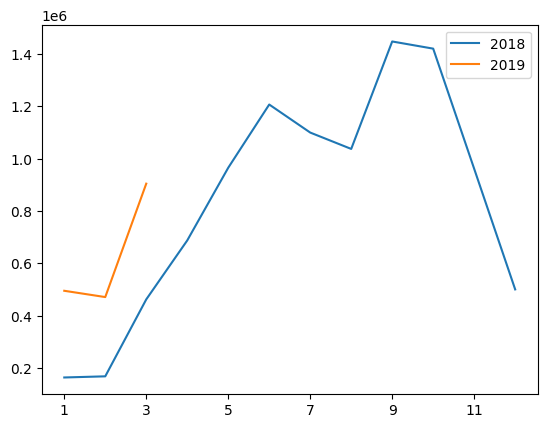

In [191]:
my.plot(kind='line')

In [192]:
#숫자는 표/ 그래프로 되지만 표는 text를 써서 보통 ML data가 된다 
#머신러닝이 아무 data나 잘 안 먹음

In [194]:
#원천 data를 가공하는 것이 매우 중요 --> ML의 결과를 낼 수 있음

In [198]:
#지금 추세는 관계형으로 많이 담는다 ( data저장을 표로 갖는다 )  ==> RDB라고 부른다

In [199]:
#ex 주소록

In [200]:
#관계형 data는 매우 많이 쓴다!

In [201]:
#오라클

In [203]:
#향후 기술은 관계형이 발전해서 OODB라는 객체지향으로 갈 거로 보임

In [204]:
#밴더, sql, 오라클 다 알고 있어야 한다

In [205]:
#spark SQL

In [206]:
#QL

In [207]:
#SQL은 다 언어에서 사용

In [208]:
#임시 table을 만드는 게 view이다

In [211]:
#table을 만드는 데 있으면 덮어쓰고 없으면 만드는 것
wcDf.createOrReplaceTempView("wc") #임시테이블 -> wc
spark.sql("select Club,Team,Year from wc").show(1) # 임시로 문자열에서 select를 할 수 있다

+--------------------+---------+----+
|                Club|     Team|Year|
+--------------------+---------+----+
|Club AtlÃ©tico Ta...|Argentina|1930|
+--------------------+---------+----+
only showing top 1 row



In [212]:
#SQL 매우매우 중요

In [213]:
wcPlayers=spark.sql("select FullName,Club,Team,Year from wc")
wcPlayers.show(1)

+------------+--------------------+---------+----+
|    FullName|                Club|     Team|Year|
+------------+--------------------+---------+----+
|Ãngel Bossio|Club AtlÃ©tico Ta...|Argentina|1930|
+------------+--------------------+---------+----+
only showing top 1 row



In [214]:
spark.catalog.listTables()

[Table(name='wc', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [215]:
namesRdd=wcPlayers.rdd.map(lambda x: "Full name: "+x[0])
for e in namesRdd.take(5):
    print (e)

Full name: Ãngel Bossio
Full name: Juan Botasso
Full name: Roberto Cherro
Full name: Alberto Chividini
Full name: 


In [216]:
#정규화

In [217]:
#정규화해서 관계형으로
#정규화는 매우 중요한데, cell의 중요한 점은 ,로 여러개가 있으면 안된다

In [218]:
bucketDf=spark.createDataFrame([[1,["orange", "apple", "pineapple"]],
                                [2,["watermelon","apple","bananas"]]],
                               ["bucketId","items"])

In [219]:
bucketDf.show(bucketDf.count(), truncate=False)

+--------+----------------------------+
|bucketId|items                       |
+--------+----------------------------+
|1       |[orange, apple, pineapple]  |
|2       |[watermelon, apple, bananas]|
+--------+----------------------------+



In [220]:
from pyspark.sql.functions import explode
bDf=bucketDf.select(bucketDf.bucketId, explode(bucketDf.items).alias('item'))

In [221]:
#분할하고 채운다

In [222]:
#cell 안에는 ,나 data가 있으면 안 된다

In [223]:
#join ==> 표가 2개 있는데 그걸 합치는 거

In [224]:
fDf=spark.createDataFrame([["orange", "F1"],
                            ["", "F2"],
                            ["pineapple","F3"],
                            ["watermelon","F4"],
                            ["bananas","F5"]],
                            ["item","itemId"])

In [225]:
#공통된 것만 가지는 inner


In [226]:
#과거의 트래픽을 봤을 때 공격을 분석하고 앞으로 예방한다

In [227]:
#KDD Cup 1999 Data 중 일부 발췌

In [234]:
import os
_url = 'http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz'
_fname = os.path.join(os.getcwd(),'data','kddcup.data_10_percent.gz')

In [235]:
#데이터 디렉토리 파일

In [236]:
_rdd = spark.sparkContext.textFile(_fname)

In [237]:
_rdd.count()

494021

In [238]:
#data 분석

In [239]:
#통계값을 구해줘야 해요

In [240]:
#집단별로 다른 걸 추출

In [241]:
#집단화해서 패턴을 파악해야해 ---> 이후에 ML

In [242]:
_rdd.take(1)

['0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,9,9,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.']

In [244]:
#굥격인지 아닌지 -> 확인해보니 정상 data???

In [245]:
#방향성을 정해야 한다

In [246]:
#,를 뜯어야 한다

In [249]:
_allRdd=_rdd.map(lambda x: x.split(','))
#문자열로 찢어짐

In [250]:

_allRdd.take(1)

[['0',
  'tcp',
  'http',
  'SF',
  '181',
  '5450',
  '0',
  '0',
  '0',
  '0',
  '0',
  '1',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '8',
  '8',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '1.00',
  '0.00',
  '0.00',
  '9',
  '9',
  '1.00',
  '0.00',
  '0.11',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  'normal.']]

In [251]:
_normalRdd=_allRdd.filter(lambda x: x[41]=="normal.")
_attackRdd=_allRdd.filter(lambda x: x[41]!="normal.")

In [252]:
_normalRdd.count()

97278

In [253]:

_attackRdd.count()

396743

In [255]:
#attack 는 도수공격(DOS) (서비스 공격 차단) (계속 내가 공격)

In [256]:
#맨 마지막 normal.이라고 된col을 쓰는 것

In [258]:
_41 = _allRdd.map(lambda x: (x[41], 1))
_41.reduceByKey(lambda x,y: x+y).collect()

[('normal.', 97278),
 ('buffer_overflow.', 30),
 ('loadmodule.', 9),
 ('perl.', 3),
 ('neptune.', 107201),
 ('smurf.', 280790),
 ('guess_passwd.', 53),
 ('pod.', 264),
 ('teardrop.', 979),
 ('portsweep.', 1040),
 ('ipsweep.', 1247),
 ('land.', 21),
 ('ftp_write.', 8),
 ('back.', 2203),
 ('imap.', 12),
 ('satan.', 1589),
 ('phf.', 4),
 ('nmap.', 231),
 ('multihop.', 7),
 ('warezmaster.', 20),
 ('warezclient.', 1020),
 ('spy.', 2),
 ('rootkit.', 10)]

In [259]:
_41 = _allRdd.map(lambda x: (x[41], 1))
def f(x): return len(x)
_41.groupByKey().mapValues(f).collect()

[('normal.', 97278),
 ('buffer_overflow.', 30),
 ('loadmodule.', 9),
 ('perl.', 3),
 ('neptune.', 107201),
 ('smurf.', 280790),
 ('guess_passwd.', 53),
 ('pod.', 264),
 ('teardrop.', 979),
 ('portsweep.', 1040),
 ('ipsweep.', 1247),
 ('land.', 21),
 ('ftp_write.', 8),
 ('back.', 2203),
 ('imap.', 12),
 ('satan.', 1589),
 ('phf.', 4),
 ('nmap.', 231),
 ('multihop.', 7),
 ('warezmaster.', 20),
 ('warezclient.', 1020),
 ('spy.', 2),
 ('rootkit.', 10)]

In [260]:
#groupByKey랑 비교하는 것

In [261]:
#rdd로 푼 것

In [262]:
#pandas DF (주식)

In [263]:
#5개의 컬럼을 (컬럼명을 지정하여) Row 형태로 총 7개로 된 컬럼 만들기

from pyspark.sql import Row

_csv = _rdd.map(lambda l: l.split(","))
_csvRdd = _csv.map(lambda p: 
    Row(
        duration=int(p[0]), 
        protocol=p[1],
        service=p[2],
        flag=p[3],
        src_bytes=int(p[4]),
        dst_bytes=int(p[5]),
        attack=p[41]
    )
)

In [264]:
#rdd -> df

_df=spark.createDataFrame(_csvRdd)

In [265]:
_df.printSchema()
_df.show(5)

root
 |-- duration: long (nullable = true)
 |-- protocol: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: long (nullable = true)
 |-- dst_bytes: long (nullable = true)
 |-- attack: string (nullable = true)

+--------+--------+-------+----+---------+---------+-------+
|duration|protocol|service|flag|src_bytes|dst_bytes| attack|
+--------+--------+-------+----+---------+---------+-------+
|       0|     tcp|   http|  SF|      181|     5450|normal.|
|       0|     tcp|   http|  SF|      239|      486|normal.|
|       0|     tcp|   http|  SF|      235|     1337|normal.|
|       0|     tcp|   http|  SF|      219|     1337|normal.|
|       0|     tcp|   http|  SF|      217|     2032|normal.|
+--------+--------+-------+----+---------+---------+-------+
only showing top 5 rows



In [266]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
attack_udf = udf(lambda x: "normal" if x =="normal." else "attack", StringType())
myDf=_df.withColumn("attackB", attack_udf(_df.attack))

In [267]:
#공격 2분화 
#groupBy 하는중

In [268]:
myDf.printSchema()

root
 |-- duration: long (nullable = true)
 |-- protocol: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: long (nullable = true)
 |-- dst_bytes: long (nullable = true)
 |-- attack: string (nullable = true)
 |-- attackB: string (nullable = true)



In [269]:
#4분기 quter 중요함

In [270]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
def classify41(s):
    _5=""
    if s=="normal.":
        _5="normal"
    elif s=="back." or s=="land." or s=="neptune." or s=="pod." or s=="smurf." or s=="teardrop.":
        _5="dos"
    elif s=="ftp_write." or s=="guess_passwd." or s=="imap." or s=="multihop." or s=="phf." or\
        s=="spy." or s=="warezclient." or s=="warezmaster.":
        _5="r2l"
    elif s=="buffer_overflow." or s=="loadmodule." or s=="perl." or s=="rootkit.":
        _5="u2r"
    elif s=="ipsweep." or s=="nmap." or s=="portsweep." or s=="satan.":
        _5="probing"
    return _5

attack5_udf = udf(classify41, StringType())

In [271]:
myDf=myDf.withColumn("attack5", attack5_udf(_df.attack))

In [272]:
myDf.printSchema()

root
 |-- duration: long (nullable = true)
 |-- protocol: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: long (nullable = true)
 |-- dst_bytes: long (nullable = true)
 |-- attack: string (nullable = true)
 |-- attackB: string (nullable = true)
 |-- attack5: string (nullable = true)



In [273]:
myDf.show(5)

+--------+--------+-------+----+---------+---------+-------+-------+-------+
|duration|protocol|service|flag|src_bytes|dst_bytes| attack|attackB|attack5|
+--------+--------+-------+----+---------+---------+-------+-------+-------+
|       0|     tcp|   http|  SF|      181|     5450|normal.| normal| normal|
|       0|     tcp|   http|  SF|      239|      486|normal.| normal| normal|
|       0|     tcp|   http|  SF|      235|     1337|normal.| normal| normal|
|       0|     tcp|   http|  SF|      219|     1337|normal.| normal| normal|
|       0|     tcp|   http|  SF|      217|     2032|normal.| normal| normal|
+--------+--------+-------+----+---------+---------+-------+-------+-------+
only showing top 5 rows



In [274]:
#집단화 했을때 다른지? 찾아보는 것

In [275]:
myDf.groupBy('attack5').count().show()

+-------+------+
|attack5| count|
+-------+------+
|probing|  4107|
|    u2r|    52|
| normal| 97278|
|    r2l|  1126|
|    dos|391458|
+-------+------+



In [279]:
#dos 공격이 제일 많구나! 라는 걸 알 수 있어

In [280]:
#집단화 끝 B랑 5로 나눴어 끝!

In [281]:
#전처리 과정 분류 완료

In [283]:
#프로토콜별로 확인
myDf.groupBy("protocol").count().show()

+--------+------+
|protocol| count|
+--------+------+
|     tcp|190065|
|     udp| 20354|
|    icmp|283602|
+--------+------+



In [285]:
#프로토콜이 총 3개로 나뉘어지고 각 몇개인지 알 수 있다

In [286]:
myDf.groupBy('attackB','protocol').count().show()

+-------+--------+------+
|attackB|protocol| count|
+-------+--------+------+
| normal|     udp| 19177|
| normal|    icmp|  1288|
| normal|     tcp| 76813|
| attack|    icmp|282314|
| attack|     tcp|113252|
| attack|     udp|  1177|
+-------+--------+------+



In [287]:
myDf.groupBy('attackB').pivot('protocol').count().show()

+-------+------+------+-----+
|attackB|  icmp|   tcp|  udp|
+-------+------+------+-----+
| normal|  1288| 76813|19177|
| attack|282314|113252| 1177|
+-------+------+------+-----+



In [288]:
#전형적인 분석법(표로 나누는 것)

In [292]:
#회사에서 표 만드는 것 ==> 왜 표를 만들까? -> 분석업무를 하는 이유 -> 감독기관에 보고등등 보고하기 위해서

In [293]:
#LLM (chatGPT) 만드는 회사는? -> 딱히 없음

In [294]:
#OLAP랑 OLTP로 업무가 나뉘어 진다

In [295]:
#SQL이 표 그리는 데에 일가견이 있다

In [296]:
myDf.groupBy('attack5').pivot('protocol').avg('src_bytes').show()

+-------+------------------+------------------+------------------+
|attack5|              icmp|               tcp|               udp|
+-------+------------------+------------------+------------------+
|probing|10.700793650793651| 261454.6003016591|25.235897435897435|
|    u2r|              NULL| 960.8979591836735|13.333333333333334|
| normal| 91.47049689440993|1439.3120305156679| 98.01220211711947|
|    r2l|              NULL|271972.57460035523|              NULL|
|    dos| 936.2672084368129| 1090.303422435458|              28.0|
+-------+------------------+------------------+------------------+



In [297]:
#5가지 종류가 있어요

In [298]:
myDf.groupBy('attack5').avg('duration').show()

+-------+--------------------+
|attack5|       avg(duration)|
+-------+--------------------+
|probing|   485.0299488677867|
|    u2r|    80.9423076923077|
| normal|  216.65732231336992|
|    r2l|   559.7522202486679|
|    dos|7.254929008986916E-4|
+-------+--------------------+



In [299]:
#특징을 파악 가능 but 여기선 네트워킹 기본 지식이 있어야 한다

In [300]:
#max값 구하기
from pyspark.sql import functions as F
myDf.groupBy('attackB').pivot('protocol').agg(F.max('dst_bytes')).show()

+-------+----+-------+---+
|attackB|icmp|    tcp|udp|
+-------+----+-------+---+
| normal|   0|5134218|516|
| attack|   0|5155468| 74|
+-------+----+-------+---+



In [301]:
myDf.select("protocol", "duration", "dst_bytes")\
    .filter(_df.duration>1000)\
    .filter(_df.dst_bytes==0)\
    .groupBy("protocol")\
    .count()\
    .show()

+--------+-----+
|protocol|count|
+--------+-----+
|     tcp|  139|
+--------+-----+



In [302]:
_df.createOrReplaceTempView("_tab")

In [303]:
tcp_interactions = spark.sql(
"""
    SELECT duration, dst_bytes FROM _tab
    WHERE protocol = 'tcp' AND duration > 1000 AND dst_bytes = 0
""")

In [304]:
tcp_interactions.show(5)

+--------+---------+
|duration|dst_bytes|
+--------+---------+
|    5057|        0|
|    5059|        0|
|    5051|        0|
|    5056|        0|
|    5051|        0|
+--------+---------+
only showing top 5 rows



In [305]:
tcp_interactions_out = tcp_interactions.rdd\
    .map(lambda p: "Duration: {}, Dest. bytes: {}".format(p.duration, p.dst_bytes))

In [306]:
for i,ti_out in enumerate(tcp_interactions_out.collect()):
    if(i%10==0):
        print (ti_out)



#일부만 출력하기 위함

Duration: 5057, Dest. bytes: 0
Duration: 5043, Dest. bytes: 0
Duration: 5046, Dest. bytes: 0
Duration: 5051, Dest. bytes: 0
Duration: 5057, Dest. bytes: 0
Duration: 5063, Dest. bytes: 0
Duration: 42448, Dest. bytes: 0
Duration: 40121, Dest. bytes: 0
Duration: 31709, Dest. bytes: 0
Duration: 30619, Dest. bytes: 0
Duration: 22616, Dest. bytes: 0
Duration: 21455, Dest. bytes: 0
Duration: 13998, Dest. bytes: 0
Duration: 12933, Dest. bytes: 0


In [307]:
#twitter 은 skip하지만 요즘엔 web 2.0(글을 쓰기 시작)부터 bigdata가 생겨나기 시작함

In [308]:
#라이브러리를 이용해서 쓰는 것

In [309]:
#그래서 난이도가 높음

In [313]:
#database에 web서버를 연결하고 web에 각각 여러 컴퓨터가 연결해서 data를 쓰는 것
#자바가 웹이고 database가 RDB임       -> 지금 오라클로 변화하는 시기

In [312]:
#JDBC 쓰는 것! 중요하다

In [315]:
#JAVA는 HP 그리고 RDB는 오라클(유료), mysQL(무료), sqllite(무료 완전 lite)

In [316]:
#lite로 해보겠다

In [317]:
#maven 은 cloud이다 그래서 파일이 cloud에 있음
#lib 파일 만들어서 jal 저장기

In [319]:
import pyspark
import os

#내려받은 거 쓸 땐 set을 이용하여 써야 한다
myConf=pyspark.SparkConf().set("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.2.0,com.databricks:spark-csv_2.11:1.5.0")\
                        .set("spark.driver.extraClassPath", os.path.join(os.getcwd(),"lib","sqlite-jdbc-3.41.0.1.jar"))
spark = pyspark.sql.SparkSession\
    .builder\
    .master("local")\
    .appName("myApp")\
    .config(conf=myConf)\
    .getOrCreate()

In [320]:
#깡통 (RDB) data의 기능은 C, R, U, D의 기능이 있다
                #     쓰고 읽고 

In [321]:
#시간이 남으면 웹에 주소록을 넣고 RDB에

In [322]:
#JAVA로 넣어서 CRUD 해보는 거 강력추천

In [323]:
spark.conf.get('spark.driver.extraClassPath')
#conf.get 으로 파일이 있으면 출력된다

'C:\\Users\\rkdus3696\\Code\\202221389\\env39\\lib\\sqlite-jdbc-3.41.0.1.jar'

In [324]:
import json

info = json.loads( '''[
    { "id" : "001", "x" : "2", "name" : "Chuck"},
    { "id" : "009", "x" : "7", "name" : "Brent" }
]''')

In [325]:

info

[{'id': '001', 'x': '2', 'name': 'Chuck'},
 {'id': '009', 'x': '7', 'name': 'Brent'}]

In [339]:
myDf= spark.read.json(spark.sparkContext.parallelize(info)) 

In [340]:

myDf.show()

+---+-----+---+
| id| name|  x|
+---+-----+---+
|001|Chuck|  2|
|009|Brent|  7|
+---+-----+---+



In [341]:
myDf.write.format('jdbc')\
    .options(
        url="jdbc:sqlite:"+os.path.join(os.getcwd(),"customer1.db"),
        dbtable="customers",
        driver="org.sqlite.JDBC"
    ).mode('overwrite').save()

Py4JJavaError: An error occurred while calling o1027.save.
: java.lang.ClassNotFoundException: org.sqlite.JDBC
	at java.base/java.net.URLClassLoader.findClass(URLClassLoader.java:445)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:593)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:526)
	at org.apache.spark.sql.execution.datasources.jdbc.DriverRegistry$.register(DriverRegistry.scala:46)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.$anonfun$driverClass$1(JDBCOptions.scala:103)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.$anonfun$driverClass$1$adapted(JDBCOptions.scala:103)
	at scala.Option.foreach(Option.scala:407)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.<init>(JDBCOptions.scala:103)
	at org.apache.spark.sql.execution.datasources.jdbc.JdbcOptionsInWrite.<init>(JDBCOptions.scala:254)
	at org.apache.spark.sql.execution.datasources.jdbc.JdbcOptionsInWrite.<init>(JDBCOptions.scala:258)


In [330]:
#JDBC를 이용하여 write 할 수 있음

In [331]:
print("jdbc:sqlite:"+os.path.join(os.getcwd(),"customer.db"))

jdbc:sqlite:C:\Users\rkdus3696\Code\202221389\env39\customer.db


In [332]:
df=spark.read.format('jdbc')\
    .options(
        url="jdbc:sqlite:"+os.path.join(os.getcwd(),"customer1.db"),
        dbtable="customers",
        driver="org.sqlite.JDBC"
    ).load()

Py4JJavaError: An error occurred while calling o985.load.
: java.lang.ClassNotFoundException: org.sqlite.JDBC
	at java.base/java.net.URLClassLoader.findClass(URLClassLoader.java:445)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:593)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:526)
	at org.apache.spark.sql.execution.datasources.jdbc.DriverRegistry$.register(DriverRegistry.scala:46)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.$anonfun$driverClass$1(JDBCOptions.scala:103)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.$anonfun$driverClass$1$adapted(JDBCOptions.scala:103)
	at scala.Option.foreach(Option.scala:407)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.<init>(JDBCOptions.scala:103)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.<init>(JDBCOptions.scala:41)
	at org.apache.spark.sql.execution.datasources.jdbc.JdbcRelationProvider.createRelation(JdbcRelationProvider.sc

In [333]:
#sqlite의 압축을 풀면 org sqlite 이런식의 파일이 있음

In [334]:
#spark버전이랑도 잘 맞아야 한다

In [1]:
#JDBC 안 나오나? -> 넹!
#이게 안 나오는거였다 12주차 다시하기 밑에부분